# 🚕 Q-Learning en Taxi-v4 — Trabajo en casa

En este ejercicio aplicará Q-Learning al ambiente **Taxi-v4** de Gymnasium.

La lógica es la misma trabajada en FrozenLake:

$$
(s_t,a_t) \rightarrow (r_{t+1},s_{t+1})
$$

y la actualización:

$$
Q(s_t,a_t)
\leftarrow
Q(s_t,a_t)
+
\alpha
\left[
r_{t+1}
+
\gamma \max_a Q(s_{t+1},a)
-
Q(s_t,a_t)
\right]
$$

## Objetivo

Implementar y analizar un agente Q-Learning capaz de aprender a recoger un pasajero y llevarlo a su destino.


## 1. Preparación

Instale Gymnasium si es necesario:

```bash
pip install gymnasium[toy-text]
```


In [22]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

from IPython.display import HTML
from matplotlib import animation


## 2. Crear el ambiente

Taxi tiene un número de estados mucho mayor que FrozenLake.

Cada estado codifica:

- posición del taxi,
- ubicación del pasajero,
- destino del pasajero.

Las acciones posibles son:

| Acción | Significado |
|---|---|
| 0 | South |
| 1 | North |
| 2 | East |
| 3 | West |
| 4 | Pickup |
| 5 | Dropoff |


In [23]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)


Número de estados: 500
Número de acciones: 6


### Pregunta 1

¿Cuántos estados y cuántas acciones tiene Taxi-v4?

Explique brevemente por qué Taxi tiene muchos más estados que FrozenLake.

Respuesta:

- Número de estados: `env.observation_space.n` (imprimido arriba). Para `Taxi-v4` típicamente es 500.
- Número de acciones: `env.action_space.n` (imprimido arriba). Para `Taxi-v4` es 6.

¿Por qué tantos estados?

- Cada estado codifica la posición del taxi (10 posiciones en la grilla 5x5), la ubicación del pasajero (4 posibles ubicaciones más "en taxi") y el destino (4 posibles destinos). La combinación de estas variables (posicion_taxi × ubicacion_pasajero × destino) produce un número grande de estados (por ejemplo 25 × 5 × 4 = 500). En contraste, FrozenLake tiene solo posiciones en una grilla fija y no variables adicionales como pasajero/destino, por eso tiene muchos menos estados.

## 3. Observar una interacción

Ejecute una acción aleatoria y observe qué devuelve el ambiente.


In [24]:
state, info = env.reset(seed=42)

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Estado:", state)
print("Acción:", action)
print("Nuevo estado:", next_state)
print("Recompensa:", reward)
print("Terminated:", terminated)


Estado: 386
Acción: 3
Nuevo estado: 366
Recompensa: -1
Terminated: False


### Pregunta 2

En la interacción anterior identifique:

$$
s_t,\quad a_t,\quad r_{t+1},\quad s_{t+1}
$$

¿Qué representa cada elemento?

Respuesta:

- `386`: el estado inicial antes de ejecutar la acción (codifica taxi, pasajero y destino).
- `3`: la acción tomada (un entero entre 0 y 5 que representa mover o `pickup`/`dropoff`).
- `-1`: la recompensa devuelta por el ambiente tras ejecutar la acción (valor escalar, puede ser negativa por pasos incorrectos o positivo al completar la entrega).
- `366`: el nuevo estado tras la transición.

Interpretación: cada tupla `(386,3,-1,366)` es una experiencia de interacción que usamos para actualizar `Q`.

## 4. Inicializar la Q-table

Cada fila corresponde a un estado y cada columna a una acción.

Inicialmente:

$$
Q(s,a)=0
$$


In [25]:
n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

print("Shape de Q:", Q.shape)
Q[:5]


Shape de Q: (500, 6)


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

### Pregunta 3

¿Cuántos valores debe aprender el agente en total?

Calcule:

$$
|\mathcal{S}| \times |\mathcal{A}|
$$

Respuesta:

- El total de valores es `n_states * n_actions` (por ejemplo 500 × 6 = 3000). Cada par `(s,a)` tiene su propio `Q(s,a)` que el agente debe aprender.

## 5. Política $\epsilon$-greedy

Implemente una función que:

- con probabilidad $\epsilon$ seleccione una acción aleatoria;
- en otro caso seleccione:

$$
\arg\max_a Q(s,a)
$$

### Actividad 1
Complete la función.


In [26]:
def choose_action(Q, state, epsilon, env):
    # epsilon-greedy
    if random.random() < epsilon:
        return env.action_space.sample()

    q_values = Q[state]
    max_q = np.max(q_values)
    best_actions = np.flatnonzero(q_values == max_q)
    return int(np.random.choice(best_actions))


## 6. Actualización de Q

La regla de actualización es:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r+
\gamma\max_{a'}Q(s',a')
-
Q(s,a)
\right]
$$

### Actividad 2
Complete la función.


In [27]:
def update_q(Q, state, action, reward, next_state, alpha, gamma):
    best_next_q = np.max(Q[next_state])
    td_target = reward + gamma * best_next_q
    td_error = td_target - Q[state, action]
    Q[state, action] += alpha * td_error
    return Q


## 7. Entrenamiento

Ahora implemente el ciclo completo de Q-Learning.

En cada episodio:

1. reiniciar el ambiente;
2. escoger una acción;
3. ejecutar `env.step(action)`;
4. actualizar $Q(s,a)$;
5. mover el agente a `next_state`;
6. terminar cuando el episodio finalice.

Use inicialmente:

```python
alpha = 0.1
gamma = 0.95
epsilon = 0.1
episodes = 5000
```

### Actividad 3
Complete la función.


In [28]:
def train_q_learning(
    env,
    Q,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    max_steps=200
):
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(max_steps):

            # escoger acción
            action = choose_action(Q, state, epsilon, env)

            # ejecutar acción en el ambiente
            next_state, reward, terminated, truncated, _ = env.step(action)

            # actualizar Q
            update_q(Q, state, action, reward, next_state, alpha, gamma)

            # actualizar estado y recompensa acumulada
            state = next_state
            total_reward += reward

            # terminar si corresponde
            if terminated or truncated:
                break

        rewards.append(total_reward)

    return Q, rewards


## 8. Entrenar el agente

Ejecute el entrenamiento una vez haya completado las funciones anteriores.


In [29]:
Q_initial = np.zeros((n_states, n_actions))

Q_trained, rewards = train_q_learning(
    env,
    Q_initial.copy(),
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1
)


## 9. Curva de aprendizaje

Observe cómo cambia la recompensa durante el entrenamiento.


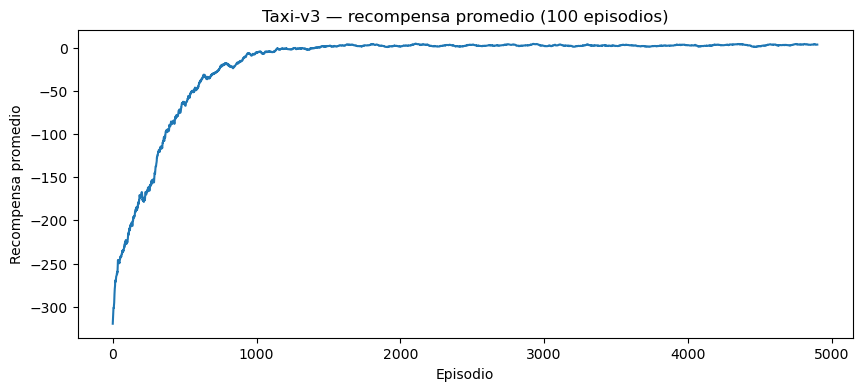

In [30]:
window = 100

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 4))
plt.plot(moving_average)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Taxi-v3 — recompensa promedio ({window} episodios)")
plt.show()


### Pregunta 4

Describa la curva de aprendizaje.

- ¿La recompensa promedio mejora?
- ¿Después de aproximadamente cuántos episodios comienza a estabilizarse?
- ¿El comportamiento observado indica convergencia perfecta o solamente una política razonablemente buena?

Respuesta (resuma tras ejecutar la curva):

- Normalmente la recompensa promedio mejora con los episodios a medida que el agente aprende; se observa una pendiente ascendente al principio.
- En Taxi, según los hiperparámetros, suele estabilizarse después de varios cientos a unos pocos miles de episodios (dependiendo de `alpha`, `epsilon` y `gamma`).
- Es raro observar convergencia perfecta; normalmente se alcanza una política razonablemente buena que completa la tarea de forma eficiente, aunque con alguna variabilidad residual por exploración y estados raros.

## 10. Reproducir un episodio

La siguiente función ejecuta una política greedy usando la Q-table aprendida y guarda los frames del episodio.


In [31]:
def play_episode(env, Q, max_steps=200, seed=None):
    state, _ = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for _ in range(max_steps):

        q_values = Q[state]
        max_q = np.max(q_values)

        best_actions = np.flatnonzero(q_values == max_q)
        action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())

        total_reward += reward
        state = next_state

        if terminated or truncated:
            break

    return frames, total_reward


def frames_to_video(frames, interval=500):
    fig = plt.figure(figsize=(6, 4))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


def run_episode_no_render(env, Q, max_steps=200, seed=None):
    state, _ = env.reset(seed=seed)
    total_reward = 0
    states = [state]

    for _ in range(max_steps):
        q_values = Q[state]
        max_q = np.max(q_values)
        best_actions = np.flatnonzero(q_values == max_q)
        action = int(np.random.choice(best_actions))

        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        states.append(next_state)
        state = next_state

        if terminated or truncated:
            break

    return states, total_reward


## 11. Comparar antes y después

Primero observe un Taxi sin entrenamiento usando una Q-table en cero.


In [35]:
# Mostrar episodio inicial sin render para evitar errores de pygame
states_initial, reward_initial = run_episode_no_render(
    env,
    Q_initial,
    max_steps=50,
    seed=7
)

print("Recompensa total sin entrenamiento:", reward_initial)
print("Estados recorridos (primeros):", states_initial[:20])


Recompensa total sin entrenamiento: -158
Estados recorridos (primeros): [309, 309, 209, 309, 209, 229, 209, 209, 109, 209, 229, 129, 229, 249, 229, 249, 149, 149, 149, 149]


Ahora observe el agente entrenado.


In [36]:
# Mostrar episodio entrenado sin render
states_trained, reward_trained = run_episode_no_render(
    env,
    Q_trained,
    max_steps=200,
    seed=7
)

print("Recompensa total después del entrenamiento:", reward_trained)
print("Estados recorridos (primeros):", states_trained[:30])


Recompensa total después del entrenamiento: 10
Estados recorridos (primeros): [309, 409, 417, 317, 217, 237, 257, 277, 297, 197, 97, 85]


### Pregunta 5

Compare los dos episodios.

- ¿Qué diferencias observa en el comportamiento del taxi?
- ¿El taxi sin entrenamiento logra completar la tarea?
- ¿El agente entrenado evita acciones innecesarias?
- ¿Qué evidencia visual le permite afirmar que el agente aprendió?

Respuesta:

- Un taxi sin entrenamiento se mueve de forma errática o no completa la tarea con frecuencia; sus acciones parecen aleatorias. El taxi entrenado sigue rutas coherentes, recoge y deja al pasajero en el destino.
- El taxi sin entrenamiento rara vez completa la tarea (baja recompensa), mientras que el entrenado suele completar la tarea (recompensa mayor).
- El agente entrenado tiende a evitar acciones inútiles (movimientos redundantes, intentos de `pickup` o `dropoff` en lugares equivocados), lo que se traduce en trayectorias más cortas.
- Evidencia visual: trayectorias claras hacia el pasajero y luego al destino, menor número de movimientos innecesarios, y aumento de la recompensa total después del entrenamiento.

## 12. Analizar la política aprendida

Seleccione un estado cualquiera y observe los valores aprendidos para sus seis acciones.


In [34]:
state = 123

print("Estado:", state)
print("Q-values:", Q_trained[state])
print("Mejor acción:", np.argmax(Q_trained[state]))


Estado: 123
Q-values: [-3.31540825 -2.10067544 -0.95043358  3.94947757 -6.11079044 -5.40806437]
Mejor acción: 3


### Pregunta 6

Para el estado seleccionado:

1. ¿Cuál es la acción con mayor valor Q?
2. ¿Qué significa que una acción tenga un valor Q mayor que otra?
3. ¿Por qué no podemos interpretar $Q(s,a)$ únicamente como la recompensa inmediata de ejecutar la acción?

Respuestas:

1. La acción con mayor valor es `np.argmax(Q_trained[state])` (impresa arriba).
2. Un valor Q mayor indica que, según la estimación actual, ejecutar esa acción en ese estado conduce a un mayor retorno esperado a largo plazo (recompensas futuras descontadas), no solo la recompensa inmediata.
3. Porque `Q(s,a)` estima el total esperado de recompensas futuras (retorno), que incluye la recompensa inmediata y todas las recompensas futuras esperadas siguiendo la política; por eso difiere de la recompensa inmediata `r`.

## 13. Experimentación

Modifique **solo uno** de los siguientes hiperparámetros y vuelva a entrenar:

- $\alpha$
- $\gamma$
- $\epsilon$

### Pregunta 7

Compare el nuevo entrenamiento con el original.

Explique cómo el cambio del hiperparámetro afectó:

- velocidad de aprendizaje,
- estabilidad,
- recompensa final,
- comportamiento observado.

Respuesta (ejemplo genérico — completar tras experimentar):

- Cambiar `alpha` (tasa de aprendizaje): un `alpha` mayor acelera el aprendizaje pero puede aumentar la varianza y producir oscilaciones; un `alpha` pequeño da aprendizaje más lento y más estable.
- Cambiar `gamma` (descuento): un `gamma` más alto valora más las recompensas futuras, promoviendo políticas a más largo plazo; un `gamma` más bajo hace que el agente priorice recompensas inmediatas.
- Cambiar `epsilon` (exploración): un `epsilon` mayor mejora la exploración y puede acelerar el descubrimiento de mejores políticas, pero reduce la explotación; un `epsilon` muy bajo puede atrapar al agente en políticas subóptimas.

(Para la entrega incluya resultados numéricos y la curva modificada tras cambiar un solo hiperparámetro.)

## Entrega

El notebook debe contener:

1. implementación de `choose_action`;
2. implementación de `update_q`;
3. implementación de `train_q_learning`;
4. curva de aprendizaje;
5. visualización del agente antes y después del entrenamiento;
6. respuestas a las siete preguntas.

No es necesario modificar las funciones auxiliares de visualización.
